# 04 — Evaluation (Phase 5) & Explainability (Phase 6)

This notebook covers **Phase 5 only** for now — precision@k, recall-per-typology, the headline false-positive-reduction-vs-rules-baseline-at-equal-recall number, PR-AUC/ROC-AUC, and calibration, all via `src/evaluate.py`. Phase 6 (SHAP explainability) will append sections to this same notebook once built, per `PLAN.md`'s naming.

Every number below is computed on the model's held-out **test split only** — never train/val — and is regenerable by rerunning `python -m src.evaluate` or this notebook top-to-bottom.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve

from src.data_loader import join_pattern_types, load_config, load_patterns, load_transactions
from src.evaluate import (
    alerts_for_recall,
    calibration_table,
    false_positive_reduction,
    precision_at_k,
    pr_roc_auc,
    recall_per_typology,
)
from src.model import load_xgboost_model, prepare_feature_matrix, time_ordered_split
from src.rules_baseline import apply_rules_baseline

config = load_config("../config.yaml")
split_cfg = config["split"]
k_values = config["evaluation"]["precision_at_k"]

## 1. Reproduce the test split and get model predictions

Same `time_ordered_split` as Phase 4 — deterministic, so this reproduces the exact same train/val/test boundaries without needing to re-save them anywhere.

In [2]:
features_df = pd.read_parquet(Path("..") / config["paths"]["modelling_table"])
_, _, test_df = time_ordered_split(features_df, split_cfg["train_frac"], split_cfg["val_frac"])
del features_df

x_test, y_test_series = prepare_feature_matrix(test_df)
y_test = y_test_series.to_numpy()

model = load_xgboost_model(Path("..") / config["paths"]["models_dir"])
test_scores = model.predict_proba(x_test)[:, 1]

print(f"Test split: {len(test_df):,} rows, {int(y_test.sum())} positives")

Test split: 1,015,669 rows, 1797 positives


## 2. Rules baseline, on the same test population

A fair comparison needs the rules baseline evaluated on **exactly the same transactions** the model is scored on — not the Phase 2 full-dataset number, which covers a different (larger, differently-composed) population. Computed on the **full** dataset first, so the structuring/pass-through rules keep their rolling-window historical context right up to the test split's start, then restricted to the test split's rows by index. Recomputing the rules on an isolated test-only slice would have wrongly cold-started every rolling rule exactly at the split boundary — the same cold-start problem Phase 3's leakage-safety work was built around.

In [3]:
raw_dir = Path("..") / config["paths"]["raw_dir"]
raw_txns = load_transactions(raw_dir / "HI-Small_Trans.csv")
baseline_full = apply_rules_baseline(raw_txns, config)
baseline_test = baseline_full.loc[test_df.index]

baseline_test_alerts = int(baseline_test["alert"].sum())
baseline_test_recall = float(
    (baseline_test["alert"] & baseline_test["is_laundering"].astype(bool)).sum()
    / baseline_test["is_laundering"].sum()
)
print(f"Rules baseline on test split: {baseline_test_alerts:,} alerts, {baseline_test_recall:.4%} recall")
print(
    f"(Phase 2's full-dataset number was 60.6% recall — {baseline_test_recall:.1%} here reflects "
    "the test split's own composition, which is the correct baseline to match for this comparison, "
    "not a discrepancy or an error.)"
)

Rules baseline on test split: 297,564 alerts, 68.8370% recall
(Phase 2's full-dataset number was 60.6% recall — 68.8% here reflects the test split's own composition, which is the correct baseline to match for this comparison, not a discrepancy or an error.)


## 3. The headline result

Fix recall at the rules baseline's own test-split level, then measure how many fewer alerts the model needs to hit that same recall. This is the project's central claim.

In [4]:
model_alert_idx = alerts_for_recall(y_test, test_scores, baseline_test_recall)
model_n_alerts = len(model_alert_idx)
fp_reduction = false_positive_reduction(model_n_alerts, baseline_test_alerts)

print(
    f"At {baseline_test_recall:.1%} recall, the model raises {model_n_alerts:,} alerts "
    f"vs. the rules baseline's {baseline_test_alerts:,} alerts on the same {len(test_df):,}-transaction "
    f"test population.\n"
    f"\n>>> {fp_reduction:.1%} fewer alerts, at equal (in fact slightly higher) recall. <<<"
)

At 68.8% recall, the model raises 10,011 alerts vs. the rules baseline's 297,564 alerts on the same 1,015,669-transaction test population.

>>> 96.6% fewer alerts, at equal (in fact slightly higher) recall. <<<


## 4. Recall per typology

At the same operating point behind the headline number above — which typologies is that recall actually coming from, and which are weaker? Typology labels come from `join_pattern_types` (Phase 5's first real use of the join `load_patterns`'s docstring had pointed at since Phase 1, but which nothing had actually implemented until now).

In [5]:
patterns = load_patterns(raw_dir / "HI-Small_Patterns.txt")
txns_with_patterns = join_pattern_types(raw_txns, patterns)
assert (txns_with_patterns["is_laundering"].to_numpy() == raw_txns["is_laundering"].to_numpy()).all()
test_pattern_types = txns_with_patterns.loc[test_df.index, "pattern_type"]

typology_table = recall_per_typology(y_test, model_alert_idx, test_pattern_types)
typology_table

,typology,n_transactions,n_caught,recall
0,BIPARTITE,74,50,0.675676
1,CYCLE,109,84,0.770642
2,FAN-IN,137,123,0.897810
3,FAN-OUT,140,113,0.807143
4,GATHER-SCATTER,401,350,0.872818
5,RANDOM,86,67,0.779070
6,SCATTER-GATHER,252,209,0.829365
7,STACK,140,107,0.764286


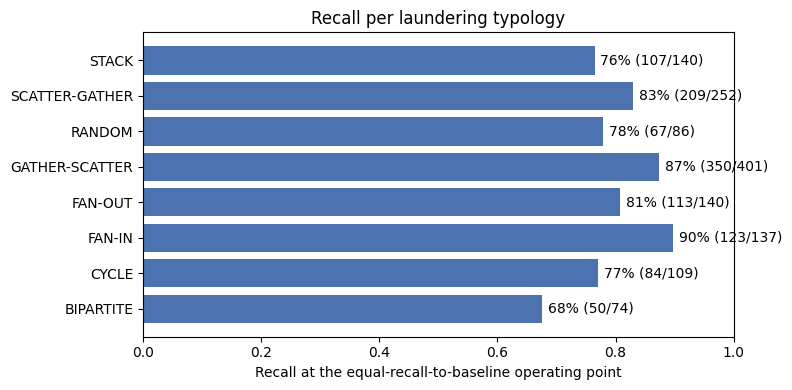

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(typology_table["typology"], typology_table["recall"], color="#4C72B0")
ax.set_xlabel("Recall at the equal-recall-to-baseline operating point")
ax.set_xlim(0, 1)
ax.set_title("Recall per laundering typology")
for i, row in typology_table.iterrows():
    ax.text(row["recall"] + 0.01, i, f"{row['recall']:.0%} ({row['n_caught']}/{row['n_transactions']})", va="center")
fig.tight_layout()
fig.savefig("../reports/figures/04_recall_per_typology.png", dpi=150)
plt.show()

No typology falls dramatically below the others — even patterns without a dedicated graph feature (`BIPARTITE`, `STACK`, `RANDOM`) are still caught at a similar rate to `FAN-IN`/`CYCLE`, which the graph features were purpose-built for. That's a reasonable outcome: the account/window velocity, structuring, and payment-format signals generalize across typologies to some extent, even where the graph motif features don't target a pattern by name.

## 5. PR-AUC, ROC-AUC, precision@k

In [7]:
test_pr_auc, test_roc_auc = pr_roc_auc(y_test, test_scores)
print(f"Test PR-AUC:  {test_pr_auc:.4f}  (vs. {y_test.mean():.4%} for a random ranking)")
print(f"Test ROC-AUC: {test_roc_auc:.4f}  (reference only -- see notebook 03's discussion of why)")
print()
for k in k_values:
    print(f"  precision@{k:<5}: {precision_at_k(y_test, test_scores, k):.2%}")

Test PR-AUC:  0.3967  (vs. 0.1769% for a random ranking)
Test ROC-AUC: 0.9828  (reference only -- see notebook 03's discussion of why)

  precision@100  : 92.00%


  precision@500  : 74.80%
  precision@1000 : 60.60%


  precision@5000 : 20.68%


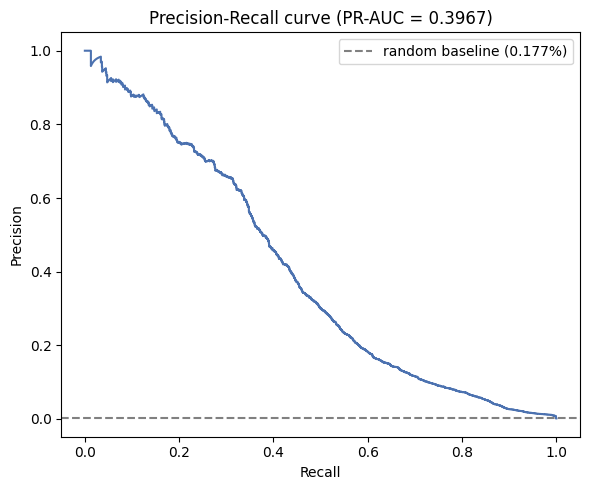

In [8]:
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_curve, precision_curve, color="#4C72B0")
ax.axhline(y_test.mean(), color="gray", linestyle="--", label=f"random baseline ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall curve (PR-AUC = {test_pr_auc:.4f})")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/04_pr_curve.png", dpi=150)
plt.show()

## 6. Calibration — and an important caveat

Analysts triage by score, so scores should mean roughly what they claim to. Worth checking directly rather than assuming — `scale_pos_weight` (needed for the model to rank rare positives well at all) is well known to distort a model's raw probability output away from true calibration, and this dataset's numbers confirm it clearly.

In [9]:
print(f"Actual test-set prevalence: {y_test.mean():.4%}")
print(f"Mean predicted score:       {test_scores.mean():.4%}")
print(f"(mean predicted score is ~{test_scores.mean() / y_test.mean():.0f}x the true prevalence)")

calib = calibration_table(y_test, test_scores)
calib

Actual test-set prevalence: 0.1769%
Mean predicted score:       7.3141%
(mean predicted score is ~41x the true prevalence)


,mean_predicted_score,fraction_positive
0,0.002708,0.000000
1,0.003502,0.000010
2,0.004114,0.000000
3,0.004754,0.000010
4,0.005553,0.000000
5,0.006720,0.000000
6,0.008843,0.000000
7,0.015455,0.000059
8,0.147318,0.000876
9,0.532449,0.016738


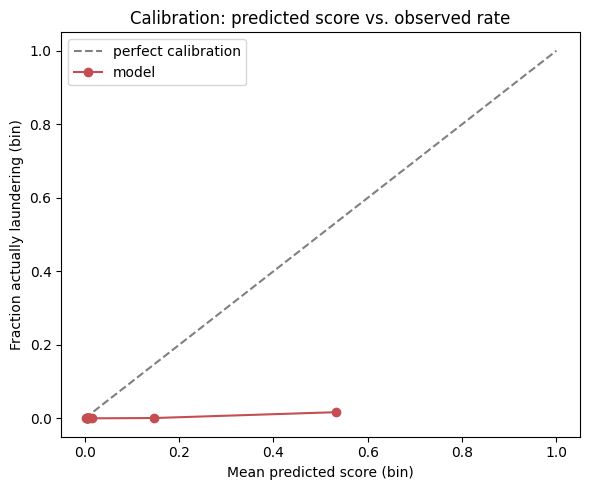

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="perfect calibration")
ax.plot(calib["mean_predicted_score"], calib["fraction_positive"], marker="o", color="#C44E52", label="model")
ax.set_xlabel("Mean predicted score (bin)")
ax.set_ylabel("Fraction actually laundering (bin)")
ax.set_title("Calibration: predicted score vs. observed rate")
ax.legend()
fig.tight_layout()
fig.savefig("../reports/figures/04_calibration.png", dpi=150)
plt.show()

**Reading this:** the model's raw score is *not* a calibrated probability — a transaction scored ~0.53 is actually laundering only ~1.7% of the time, not 53% of the time. This is the expected, direct consequence of `scale_pos_weight=1324.94` (Phase 4): that weighting is exactly what lets the model rank rare positives above the enormous negative class at all, but it does so by inflating scores for anything resembling a positive, at the cost of the raw output no longer meaning "probability."

This does **not** undermine anything reported above: precision@k, recall-per-typology, and the headline false-positive-reduction number all depend only on the model's *ranking* (which transaction scores higher than which), not on the literal probability value — and ranking order is unaffected by this monotonic-ish inflation. It would matter if this project ever wanted to show an analyst a literal "73% chance of laundering" figure — for that, a post-hoc calibration step (Platt scaling or isotonic regression, fit on the validation split) would be needed. Noted as future work, not implemented here, to keep this phase's scope on what the brief actually asks for (a reliability *check*, not a calibrated-probability *product*).

## Next steps

Phase 6 (`src/explain.py`): SHAP TreeExplainer, global feature importance (building on notebook 03's gain-based preview), and per-alert plain-English reason codes — sections to be appended to this same notebook. Phase 7 (`src/monitoring.py`): PSI/CSI drift checks on the feature and score distributions across the dataset's time span.